In [1]:

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.cm as cm
import pandas as pd



In [2]:
#parse the foodweb data

file_path = "Foodweb/data.xls"


#read the data
data = pd.read_excel(file_path)
#There are 2 different data sets in the file (ID,TSN,Name,Phylum) then a gap and it repeats again for the second data set (ID,TSN,Name,Phylum)
#separate the data into 2 dataframes
intertidal = data.iloc[:, :4]
#keep data1 until the first nan value row
intertidal = intertidal[intertidal.notna().all(axis=1)]
nearshore = data.iloc[:, 5:]






print(nearshore)


    Sanak Nearshore Marine Food Web Unnamed: 6         Unnamed: 7  \
0                                ID        TSN               Name   
1                                 1      10031        Gymnodinium   
2                                 2      10212         Peridinium   
3                                 3      10340    Protoperidinium   
4                                 4      10359          Gonyaulax   
..                              ...        ...                ...   
509                             509     179725       Corvus corax   
510                             510     554029  Aethia psittacula   
511                             511     554127   Anthus rubescens   
512                             512     686683    Bubo scandiacus   
513                             513      78536  Cinclus mexicanus   

          Unnamed: 8  
0             Phylum  
1    Pyrrophycophyta  
2    Pyrrophycophyta  
3    Pyrrophycophyta  
4    Pyrrophycophyta  
..               ...  
509       

In [3]:
# This cell was redundant - removed

In [4]:
#check the Trophic Links sheet

trophic_links = pd.read_excel(file_path, sheet_name="Trophic Links")

print(trophic_links)




     Sanak Intertidal Food Web Unnamed: 1  Unnamed: 2  \
0                     Consumer   Resource         NaN   
1                            9          9         NaN   
2                            9         64         NaN   
3                            9         87         NaN   
4                            9        150         NaN   
...                        ...        ...         ...   
6770                       NaN        NaN         NaN   
6771                       NaN        NaN         NaN   
6772                       NaN        NaN         NaN   
6773                       NaN        NaN         NaN   
6774                       NaN        NaN         NaN   

     Sanak Nearshore Marine Food Web Unnamed: 4  
0                           Consumer   Resource  
1                                  1        200  
2                                  1        241  
3                                  1        244  
4                                  2          1  
...            

In [5]:
#separate the data into 2 dataframes (ID,ID) gap (ID,ID)
intertidal_links = trophic_links.iloc[:, :2]
#also remove the rows with nan value
intertidal_links = intertidal_links[intertidal_links.notna().all(axis=1)]
nearshore_links = trophic_links.iloc[:, 3:5]  # Fix: Only take 2 columns, not all remaining
#also remove the rows with nan value for nearshore links
nearshore_links = nearshore_links[nearshore_links.notna().all(axis=1)]

#print the dataframes
print(intertidal_links)


     Sanak Intertidal Food Web Unnamed: 1
0                     Consumer   Resource
1                            9          9
2                            9         64
3                            9         87
4                            9        150
...                        ...        ...
1800                       234        226
1801                       234        228
1802                       234        229
1803                       234        230
1804                       235         73

[1805 rows x 2 columns]


In [6]:
print(nearshore_links)

     Sanak Nearshore Marine Food Web Unnamed: 4
0                           Consumer   Resource
1                                  1        200
2                                  1        241
3                                  1        244
4                                  2          1
...                              ...        ...
6770                             512        504
6771                             512        506
6772                             512        507
6773                             512        508
6774                             513        217

[6775 rows x 2 columns]


In [7]:
#the first row is the title row, so we need to use it as the header but not as a row

intertidal.columns = intertidal.iloc[0]


intertidal = intertidal.iloc[1:]

intertidal.head()




,ID,TSN,Name,Phylum
1,1,10824,Pilayella littoralis,Phaeophyta
2,2,11217,Laminaria,Phaeophyta
3,3,11246,Agarum,Phaeophyta
4,4,11250,Costaria costata,Phaeophyta
5,5,11255,Saccharina sessile,Phaeophyta


In [8]:
#same for nearshore
nearshore.columns=nearshore.iloc[0]
nearshore=nearshore.iloc[1:]

nearshore.head()

,ID,TSN,Name,Phylum
1,1,10031,Gymnodinium,Pyrrophycophyta
2,2,10212,Peridinium,Pyrrophycophyta
3,3,10340,Protoperidinium,Pyrrophycophyta
4,4,10359,Gonyaulax,Pyrrophycophyta
5,5,10397,Ceratium,Pyrrophycophyta


In [9]:
#same for intertidal links
intertidal_links.columns = intertidal_links.iloc[0]
intertidal_links = intertidal_links.iloc[1:]


intertidal_links.head()


,Consumer,Resource
1,9,9
2,9,64
3,9,87
4,9,150
5,9,168


In [10]:
#same for nearshore links
nearshore_links.columns = nearshore_links.iloc[0]
nearshore_links = nearshore_links.iloc[1:]
nearshore_links.head()


,Consumer,Resource
1,1,200
2,1,241
3,1,244
4,2,1
5,2,2


In [11]:
#now we have the dataframe of the nodes and the links
#first lets check if all the nodes of the smallest network are present in the other network
#lets check the intertidal network
#get the TSNS of the intertidal network(the second column)
intertidal_TSNS = intertidal.iloc[:, 1]
#get the TSNS of the nearshore network(the second column)
nearshore_TSNS = nearshore.iloc[:, 1]
#print the length of the nodes
print(len(intertidal_TSNS))
print(len(nearshore_TSNS))



233
513


In [12]:
#since intetidal has less we will check if all the nodes of the intertidal network are present in the nearshore network
#summarize the results
print(intertidal_TSNS.isin(nearshore_TSNS).value_counts())
#almost all of them are present but not all so we cannot disregard it 
#however we can merge the two datasets and add two columns to indicate if the species is intertidal and/or nearshore

#print the intertidals that are not in the nearshore
print(intertidal_TSNS[~intertidal_TSNS.isin(nearshore_TSNS)])


TSN
True     226
False      7
Name: count, dtype: int64
64      2286
66     43781
69     46211
112    73727
151     9512
153    95500
162     9874
Name: TSN, dtype: object


In [13]:
#first lets merge the two datasets but without the ID column
#select only TSN, Name, and Phylum columns for merging
intertidal_clean = intertidal[["TSN", "Name", "Phylum"]].copy()
nearshore_clean = nearshore[["TSN", "Name", "Phylum"]].copy()

merged_data = pd.merge(intertidal_clean, nearshore_clean, on="TSN", how="outer", suffixes=('_intertidal', '_nearshore'))

#combine Name and Phylum columns - use intertidal values first, then nearshore if intertidal is NaN
merged_data["Name"] = merged_data["Name_intertidal"].fillna(merged_data["Name_nearshore"])
merged_data["Phylum"] = merged_data["Phylum_intertidal"].fillna(merged_data["Phylum_nearshore"])

#drop the separate columns
merged_data = merged_data.drop(["Name_intertidal", "Name_nearshore", "Phylum_intertidal", "Phylum_nearshore"], axis=1)

#add the two columns
merged_data["Intertidal"] = merged_data["TSN"].isin(intertidal_TSNS)
merged_data["Nearshore"] = merged_data["TSN"].isin(nearshore_TSNS)

print(merged_data)

0       TSN                      Name           Phylum  Intertidal  Nearshore
0       601              Cyanophycota     Cyanophycota        True       True
1      1447               Chrysophyta      Chrysophyta        True       True
2      2135          Prymnesiophyceae       Haptophyta        True       True
3      2286           Bacillariophyta  Bacillariophyta        True      False
4      2546             Coscinodiscus  Bacillariophyta       False       True
..      ...                       ...              ...         ...        ...
515  san419            Phyllobothrium  Platyhelminthes       False       True
516  san420     Nybelinia surmenicola  Platyhelminthes       False       True
517  san455             Thalassomyces         Protozoa       False       True
518  san788  Hysterothylacium aduncum           Nemata       False       True
519  san934           Pseudoterranova           Nemata       False       True

[520 rows x 5 columns]


In [14]:
#now we also need to merge the links but before we do that we need to change the ID's to TSN's
#starting from intertidal dataset we create a dictionary of the ID and TSN
intertidal_ID_TSN = dict(zip(intertidal["ID"], intertidal["TSN"]))
#now we can use this dictionary to map the ID's to TSN's in the intertidal_links dataframe
intertidal_links_TSN = intertidal_links.copy()
intertidal_links_TSN["Consumer"] = intertidal_links_TSN["Consumer"].map(intertidal_ID_TSN)
intertidal_links_TSN["Resource"] = intertidal_links_TSN["Resource"].map(intertidal_ID_TSN)

# Remove rows where mapping failed (NaN values)
intertidal_links_TSN = intertidal_links_TSN.dropna()
print(intertidal_links_TSN)

#now we do the same for the nearshore dataset
nearshore_ID_TSN = dict(zip(nearshore["ID"], nearshore["TSN"]))
#now we can use this dictionary to map the ID's to TSN's in the nearshore_links dataframe
nearshore_links_TSN = nearshore_links.copy()
nearshore_links_TSN["Consumer"] = nearshore_links_TSN["Consumer"].map(nearshore_ID_TSN)
nearshore_links_TSN["Resource"] = nearshore_links_TSN["Resource"].map(nearshore_ID_TSN)

# Remove rows where mapping failed (NaN values)
nearshore_links_TSN = nearshore_links_TSN.dropna()
print(nearshore_links_TSN)





0    Consumer Resource
1      113265   113265
2      113265     2286
3      113265      601
4      113265    93295
6        1447   202421
...       ...      ...
1800   686683   177935
1801   686683   179492
1802   686683   179526
1803   686683   179531
1804    78536    48739

[1689 rows x 2 columns]
0    Consumer Resource
1       10031     2135
2       10031   590745
3       10031      601
4       10212    10031
5       10212    10212
...       ...      ...
6770   686683   177935
6771   686683   179492
6772   686683   179526
6773   686683   179531
6774    78536    48739

[6774 rows x 2 columns]


In [15]:
# We want to create a merged links dataframe with one row per unique (Consumer, Resource) pair,
# and two columns: 'Intertidal' and 'Nearshore', indicating presence (True/False) in each network.

# First, get sets of (Consumer, Resource) tuples for each network
intertidal_links_set = set(tuple(x) for x in intertidal_links_TSN[["Consumer", "Resource"]].values)
nearshore_links_set = set(tuple(x) for x in nearshore_links_TSN[["Consumer", "Resource"]].values)

# Get all unique links
all_links = intertidal_links_set.union(nearshore_links_set)

# Build the merged DataFrame
merged_links = pd.DataFrame(list(all_links), columns=["Consumer", "Resource"])
merged_links["Intertidal"] = merged_links.apply(lambda row: (row["Consumer"], row["Resource"]) in intertidal_links_set, axis=1)
merged_links["Nearshore"] = merged_links.apply(lambda row: (row["Consumer"], row["Resource"]) in nearshore_links_set, axis=1)

print(merged_links)



     Consumer Resource  Intertidal  Nearshore
0      157215   157215       False       True
1       73293    89609        True       True
2      157152   202421        True       True
3      165427    97106       False       True
4      172932    97774       False       True
...       ...      ...         ...        ...
6912   175062     6501        True       True
6913   177013   667083       False       True
6914   164722    82415       False       True
6915    85524   158650       False       True
6916   180480   167123       False       True

[6917 rows x 4 columns]


In [16]:
#now create an nx graph from the merged links dataframe but also use the metadata from the merged_data dataframe

# Create a directed graph
G = nx.DiGraph()

# Add nodes for all unique TSNs in merged_links, with metadata from merged_data if available
all_TSNs = set(merged_links["Consumer"]).union(set(merged_links["Resource"]))

# merged_data should have TSN as a column; if not, adjust accordingly
for tsn in all_TSNs:
    # Try to get metadata for this TSN from merged_data
    if "TSN" in merged_data.columns:
        meta = merged_data[merged_data["TSN"] == tsn]
        if not meta.empty:
            node_attrs = meta.iloc[0].to_dict()
        else:
            node_attrs = {}
    else:
        node_attrs = {}
    G.add_node(tsn, **node_attrs)

# Add edges with attributes for Intertidal and Nearshore presence
for _, row in merged_links.iterrows():
    consumer = row["Consumer"]
    resource = row["Resource"]
    intertidal = row["Intertidal"]
    nearshore = row["Nearshore"]
    G.add_edge(consumer, resource, Intertidal=intertidal, Nearshore=nearshore)




C:\Users\thano\AppData\Local\Temp\ipykernel_8128\2137606884.py:31: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  legend_elements = [plt.scatter([], [], c=color, s=100, label=phylum) for phylum, color in phylum_colors.items()]
C:\Users\thano\AppData\Local\Temp\ipykernel_8128\2137606884.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


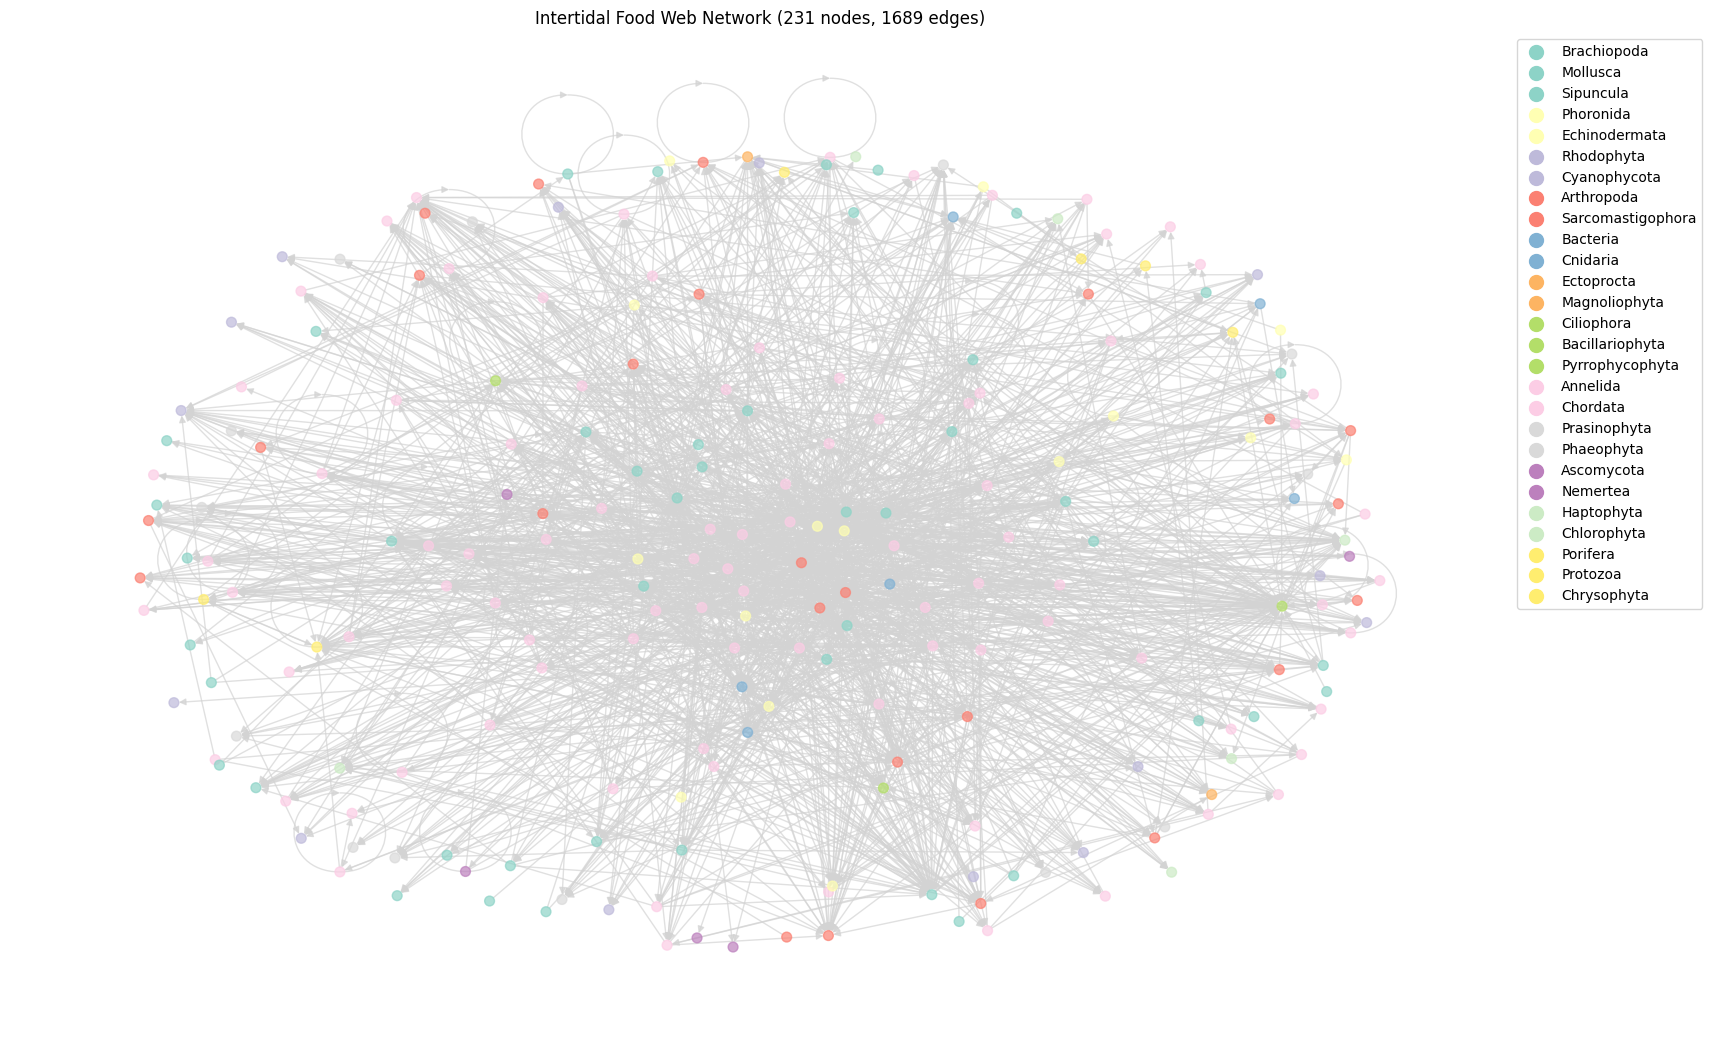

In [17]:
#using the graph filter only the intertidal links
#filter edges directly from G based on edge attributes
intertidal_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("Intertidal") == True]
#create subgraph
intertidal_G = G.edge_subgraph(intertidal_edges)

#visualize the intertidal graph with better layout and styling
plt.figure(figsize=(15, 10))

# Use spring layout for better positioning
pos = nx.spring_layout(intertidal_G, k=1, iterations=50)

# Draw nodes with different colors based on phylum
phyla = [intertidal_G.nodes[node].get('Phylum', 'Unknown') for node in intertidal_G.nodes()]
unique_phyla = list(set(phyla))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_phyla)))
phylum_colors = dict(zip(unique_phyla, colors))
node_colors = [phylum_colors.get(intertidal_G.nodes[node].get('Phylum', 'Unknown'), 'gray') for node in intertidal_G.nodes()]

# Draw the graph
nx.draw(intertidal_G, pos, 
        node_color=node_colors,
        node_size=50,
        with_labels=False,  # Remove labels for cleaner look
        edge_color='lightgray',
        alpha=0.7,
        arrows=True,
        arrowsize=10)

# Add legend for phyla
legend_elements = [plt.scatter([], [], c=color, s=100, label=phylum) for phylum, color in phylum_colors.items()]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.title(f'Intertidal Food Web Network ({intertidal_G.number_of_nodes()} nodes, {intertidal_G.number_of_edges()} edges)')
plt.tight_layout()
plt.show()


In [18]:
# Create nearshore subgraph
nearshore_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("Nearshore") == True]
nearshore_G = G.edge_subgraph(nearshore_edges)

print(f"Nearshore graph created: {nearshore_G.number_of_nodes()} nodes, {nearshore_G.number_of_edges()} edges")


Nearshore graph created: 513 nodes, 6774 edges


In [19]:
#iterate through edges 
both=0
one=0
for edge in G.edges(data=True):
    #check if both nodes are intertidal and nearshore

    if G.nodes[edge[0]]["Intertidal"] and G.nodes[edge[0]]["Nearshore"] and G.nodes[edge[1]]["Intertidal"] and G.nodes[edge[1]]["Nearshore"]:
        #if the edge is both intertidal and nearshore add 1 to both
        if edge[2]["Intertidal"] and edge[2]["Nearshore"]:
            both+=1
            print(edge)
            print(G.nodes[edge[0]])
            print(G.nodes[edge[1]])
        else:
            one+=1
print(both)
print(one)


(69662, 12322, {'Intertidal': True, 'Nearshore': True})
{'TSN': 69662, 'Name': 'Acmaea mitra', 'Phylum': 'Mollusca', 'Intertidal': True, 'Nearshore': True}
{'TSN': 12322, 'Name': 'Corallina', 'Phylum': 'Rhodophyta', 'Intertidal': True, 'Nearshore': True}
(69662, 11255, {'Intertidal': True, 'Nearshore': True})
{'TSN': 69662, 'Name': 'Acmaea mitra', 'Phylum': 'Mollusca', 'Intertidal': True, 'Nearshore': True}
{'TSN': 11255, 'Name': 'Saccharina sessile', 'Phylum': 'Phaeophyta', 'Intertidal': True, 'Nearshore': True}
(69662, 'san262', {'Intertidal': True, 'Nearshore': True})
{'TSN': 69662, 'Name': 'Acmaea mitra', 'Phylum': 'Mollusca', 'Intertidal': True, 'Nearshore': True}
{'TSN': 'san262', 'Name': 'Crustose coralline algae complex', 'Phylum': 'Rhodophyta', 'Intertidal': True, 'Nearshore': True}
(69662, 13080, {'Intertidal': True, 'Nearshore': True})
{'TSN': 69662, 'Name': 'Acmaea mitra', 'Phylum': 'Mollusca', 'Intertidal': True, 'Nearshore': True}
{'TSN': 13080, 'Name': 'Microcladia', 'Ph

In [20]:
#print all Phylum names ONCE 
phylum_names = set()
for node in G.nodes():
    phylum = G.nodes[node].get('Phylum', 'Unknown')
    phylum_names.add(phylum)
    #if the phylum is unknown or nan print it
for phylum in phylum_names:
    print(phylum)




Brachiopoda
Mollusca
Sipuncula
Phoronida
Echinodermata
nan
Rhodophyta
Cyanophycota
Platyhelminthes
Arthropoda
Sarcomastigophora
Nemata
Bacteria
Cnidaria
Ectoprocta
Magnoliophyta
Acanthocephala
Ciliophora
Echiura
Bacillariophyta
Pyrrophycophyta
Chaetognatha
Annelida
Chordata
Prasinophyta
Phaeophyta
Ascomycota
Nemertea
Chlorophyta
Haptophyta
Porifera
Protozoa
Chrysophyta


In [21]:
# Check for nodes with missing phylum information
print("Checking for nodes with missing phylum information:")
nan_phylum_nodes = []
for node in G.nodes():
    phylum = G.nodes[node].get('Phylum', 'Unknown')
    if pd.isna(phylum) or phylum == 'nan' or phylum == '':
        nan_phylum_nodes.append(node)

print(f"Found {len(nan_phylum_nodes)} nodes with missing phylum information:")
for i, node in enumerate(nan_phylum_nodes[:10]):  # Show first 10
    node_data = G.nodes[node]
    print(f"  {i+1}. TSN: {node_data.get('TSN', 'N/A')}, Name: {node_data.get('Name', 'N/A')}")

if len(nan_phylum_nodes) > 10:
    print(f"  ... and {len(nan_phylum_nodes) - 10} more nodes")

# Show statistics about phylum distribution
print(f"\nPhylum distribution in the network:")
phylum_counts = {}
for node in G.nodes():
    phylum = G.nodes[node].get('Phylum', 'Unknown')
    if pd.isna(phylum) or phylum == 'nan':
        phylum = 'Unknown/Missing'
    phylum_counts[phylum] = phylum_counts.get(phylum, 0) + 1

# Sort by count and show all phyla
sorted_phyla = sorted(phylum_counts.items(), key=lambda x: x[1], reverse=True)
for phylum, count in sorted_phyla:
    print(f"  {phylum}: {count} nodes")

# Show all nodes with 'nan' phylum in detail
if nan_phylum_nodes:
    print(f"\nDetailed view of all {len(nan_phylum_nodes)} nodes with missing phylum:")
    for i, node in enumerate(nan_phylum_nodes):
        node_data = G.nodes[node]
        print(f"  {i+1}. TSN: {node_data.get('TSN', 'N/A')}, Name: {node_data.get('Name', 'N/A')}, Phylum: {node_data.get('Phylum', 'N/A')}")
        print(f"      Intertidal: {node_data.get('Intertidal', 'N/A')}, Nearshore: {node_data.get('Nearshore', 'N/A')}")
        print(f"      In-degree: {G.in_degree(node)}, Out-degree: {G.out_degree(node)}")
        print()


Checking for nodes with missing phylum information:
Found 2 nodes with missing phylum information:
  1. TSN: san272, Name: Biofilm Complex
  2. TSN: san266, Name: Detritus complex

Phylum distribution in the network:
  Chordata: 232 nodes
  Mollusca: 67 nodes
  Arthropoda: 63 nodes
  Annelida: 26 nodes
  Echinodermata: 23 nodes
  Bacillariophyta: 15 nodes
  Rhodophyta: 13 nodes
  Phaeophyta: 12 nodes
  Pyrrophycophyta: 9 nodes
  Platyhelminthes: 9 nodes
  Cnidaria: 9 nodes
  Chlorophyta: 5 nodes
  Nemertea: 4 nodes
  Nemata: 4 nodes
  Porifera: 3 nodes
  Protozoa: 3 nodes
  Unknown/Missing: 2 nodes
  Sarcomastigophora: 2 nodes
  Acanthocephala: 2 nodes
  Ciliophora: 2 nodes
  Prasinophyta: 2 nodes
  Ascomycota: 2 nodes
  Haptophyta: 1 nodes
  Magnoliophyta: 1 nodes
  Cyanophycota: 1 nodes
  Chaetognatha: 1 nodes
  Brachiopoda: 1 nodes
  Sipuncula: 1 nodes
  Echiura: 1 nodes
  Chrysophyta: 1 nodes
  Bacteria: 1 nodes
  Phoronida: 1 nodes
  Ectoprocta: 1 nodes

Detailed view of all 2 nod

Phylum graph has 33 nodes and 190 edges


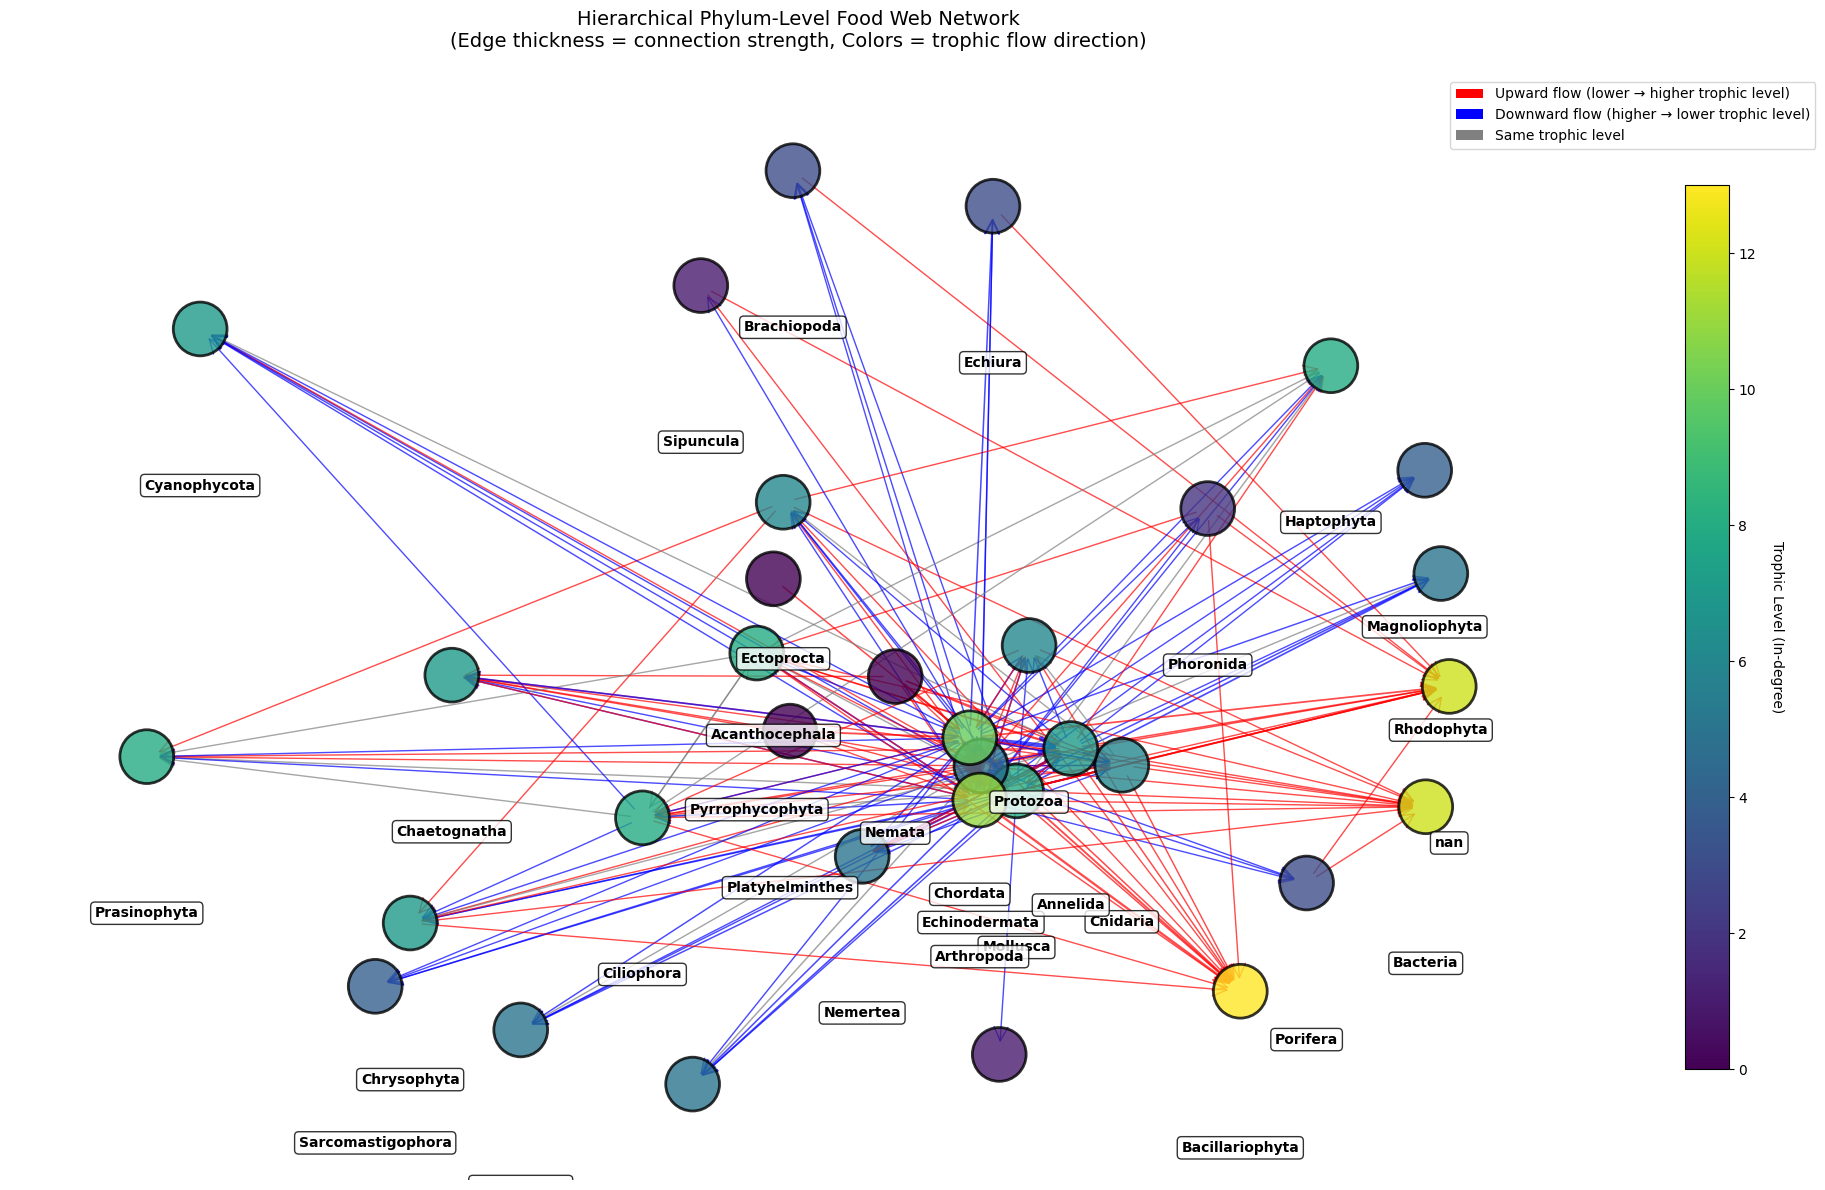


Top 10 phylum connections (by number of edges):
1. Chordata -> Chordata: 1715 connections
2. Chordata -> Arthropoda: 1559 connections
3. Chordata -> Mollusca: 540 connections
4. Chordata -> Annelida: 400 connections
5. Arthropoda -> Bacillariophyta: 134 connections
6. Echinodermata -> Mollusca: 121 connections
7. Arthropoda -> Arthropoda: 114 connections
8. Chordata -> Echinodermata: 107 connections
9. Nemata -> Chordata: 84 connections
10. Arthropoda -> Mollusca: 83 connections


In [22]:
#now we want to make another graph where we group the nodes by their phylum and we make an edge between them if they are connected in the original graph

# Create a new graph where nodes represent phyla
phylum_graph = nx.DiGraph()

# Get all unique phyla from the original graph
phyla = set()
for node in G.nodes():
    phylum = G.nodes[node].get('Phylum', 'Unknown')
    phyla.add(phylum)

# Add phylum nodes to the new graph
for phylum in phyla:
    phylum_graph.add_node(phylum)

# Count connections between phyla
phylum_connections = {}
for edge in G.edges(data=True):
    source_node = edge[0]
    target_node = edge[1]
    
    source_phylum = G.nodes[source_node].get('Phylum', 'Unknown')
    target_phylum = G.nodes[target_node].get('Phylum', 'Unknown')
    
    # Create edge key for the phylum connection
    edge_key = (source_phylum, target_phylum)
    
    # Count the number of connections between these phyla
    if edge_key in phylum_connections:
        phylum_connections[edge_key] += 1
    else:
        phylum_connections[edge_key] = 1

# Add edges between phyla with weights representing connection counts
for (source_phylum, target_phylum), count in phylum_connections.items():
    if source_phylum != target_phylum:  # Don't add self-loops
        phylum_graph.add_edge(source_phylum, target_phylum, weight=count)

print(f"Phylum graph has {phylum_graph.number_of_nodes()} nodes and {phylum_graph.number_of_edges()} edges")

# Create hierarchical layout for the phylum-level network
plt.figure(figsize=(20, 12))

# Initialize levels dictionary - always define this outside try block
levels = {}

# Calculate hierarchical positions based on trophic levels
# Use networkx's topological sort to determine hierarchy
try:
    # Try to find a topological ordering
    topo_order = list(nx.topological_sort(phylum_graph))
    
    # If the graph has cycles, use strongly connected components
    if len(topo_order) != phylum_graph.number_of_nodes():
        scc = list(nx.strongly_connected_components(phylum_graph))
        # Flatten the strongly connected components
        topo_order = [node for component in scc for node in component]
    
    # Create hierarchical levels based on connectivity
    processed = set()
    
    # Assign levels based on in-degree (trophic level)
    for node in phylum_graph.nodes():
        in_degree = phylum_graph.in_degree(node)
        levels[node] = in_degree
    
    # Normalize levels to create distinct horizontal layers
    unique_levels = sorted(set(levels.values()))
    level_mapping = {level: i for i, level in enumerate(unique_levels)}
    
    # Create hierarchical positions
    pos = {}
    level_counts = {}
    
    for node in phylum_graph.nodes():
        level = level_mapping[levels[node]]
        if level not in level_counts:
            level_counts[level] = 0
        pos[node] = (level_counts[level], level)
        level_counts[level] += 1
    
    # Adjust spacing between levels
    for node in pos:
        pos[node] = (pos[node][0] * 3, pos[node][1] * 4)

except:
    # Fallback to spring layout if hierarchical layout fails
    pos = nx.spring_layout(phylum_graph, k=3, iterations=100)
    # Still assign levels based on in-degree for coloring
    for node in phylum_graph.nodes():
        in_degree = phylum_graph.in_degree(node)
        levels[node] = in_degree

# Draw nodes with colors based on hierarchical level
node_colors = []
for node in phylum_graph.nodes():
    level = levels.get(node, 0)
    # Use a colormap to assign colors based on trophic level
    color_value = level / max(levels.values()) if levels.values() else 0
    node_colors.append(color_value)

# Draw nodes
nx.draw_networkx_nodes(phylum_graph, pos, 
                      node_color=node_colors,
                      cmap=plt.cm.viridis,
                      node_size=1500,
                      alpha=0.8,
                      edgecolors='black',
                      linewidths=2)

# Draw edges with thickness proportional to weight
edges = phylum_graph.edges()
weights = [phylum_graph[u][v]['weight'] for u, v in edges]

# Normalize weights for visualization
if weights:
    max_weight = max(weights)
    min_weight = min(weights)
    if max_weight > min_weight:
        normalized_weights = [(w - min_weight) / (max_weight - min_weight) * 8 + 1 for w in weights]
    else:
        normalized_weights = [3] * len(weights)
else:
    normalized_weights = [3]

# Color edges based on direction (hierarchical flow)
edge_colors = []
for u, v in edges:
    u_level = levels.get(u, 0)
    v_level = levels.get(v, 0)
    if u_level < v_level:  # Going up the hierarchy
        edge_colors.append('red')
    elif u_level > v_level:  # Going down the hierarchy
        edge_colors.append('blue')
    else:  # Same level
        edge_colors.append('gray')

nx.draw_networkx_edges(phylum_graph, pos,
                      width=normalized_weights,
                      alpha=0.7,
                      edge_color=edge_colors,
                      arrows=True,
                      arrowsize=25,
                      arrowstyle='->')

# Add labels with better positioning
label_pos = {}
for node, (x, y) in pos.items():
    label_pos[node] = (x, y - 0.3)  # Offset labels below nodes

nx.draw_networkx_labels(phylum_graph, label_pos,
                       font_size=10,
                       font_weight='bold',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Add colorbar for trophic levels
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=max(levels.values())))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.8)
cbar.set_label('Trophic Level (In-degree)', rotation=270, labelpad=20)

# Add legend for edge colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='Upward flow (lower → higher trophic level)'),
                  Patch(facecolor='blue', label='Downward flow (higher → lower trophic level)'),
                  Patch(facecolor='gray', label='Same trophic level')]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))

plt.title('Hierarchical Phylum-Level Food Web Network\n(Edge thickness = connection strength, Colors = trophic flow direction)', 
          fontsize=14, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

# Print some statistics about phylum connections
print("\nTop 10 phylum connections (by number of edges):")
sorted_connections = sorted(phylum_connections.items(), key=lambda x: x[1], reverse=True)
for i, ((source, target), count) in enumerate(sorted_connections[:10]):
    print(f"{i+1}. {source} -> {target}: {count} connections")



In [23]:
# Import required libraries for link prediction
from sklearn.metrics import roc_curve, roc_auc_score
import random

# Define similarity functions for directed graphs

def directed_jaccard_coefficient(G, u, v):
    """Compute a symmetric Jaccard coefficient using both in- and out-neighbors."""
    neigh_u = set(G.successors(u)) | set(G.predecessors(u))
    neigh_v = set(G.successors(v)) | set(G.predecessors(v))
    if not neigh_u or not neigh_v:
        return 0.0
    return len(neigh_u & neigh_v) / len(neigh_u | neigh_v)


def directed_preferential_attachment(G, u, v):
    """Directed preferential attachment = outdegree(u) * indegree(v)."""
    return G.out_degree(u) * G.in_degree(v)


# Leave-one-out prediction functions

def getPredictionsLeaveOneOutDirectedJaccard(G, n_neg=20):
    """
    Leave-one-out link prediction using directed Jaccard.
    For each removed edge, compute similarity for that edge (positive)
    and n_neg random non-edges (negatives).
    """
    probs, labels = [], []
    nodes = list(G.nodes())
    all_possible_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    for e in list(G.edges()):
        u, v = e
        Gprobed = G.copy()
        Gprobed.remove_edge(u, v)

        p_pos = directed_jaccard_coefficient(Gprobed, u, v)
        probs.append(p_pos)
        labels.append(1)

        non_edges = [(a, b) for (a, b) in all_possible_pairs if not Gprobed.has_edge(a, b)]

        if not non_edges:
            continue  

        sampled_non_edges = random.sample(non_edges, min(n_neg, len(non_edges)))
        for (a, b) in sampled_non_edges:
            p_neg = directed_jaccard_coefficient(Gprobed, a, b)
            probs.append(p_neg)
            labels.append(0)

    return probs, labels


def getPredictionsLeaveOneOutDirectedPA(G, n_neg=20):
    """
    Leave-one-out link prediction using directed preferential attachment.
    For each removed edge, compute the score for that edge (positive)
    and n_neg random non-edges (negatives).
    """
    probs, labels = [], []
    nodes = list(G.nodes())

    for e in list(G.edges()):
        u, v = e
        Gprobed = G.copy()
        Gprobed.remove_edge(u, v)

        p_pos = directed_preferential_attachment(Gprobed, u, v)
        probs.append(p_pos)
        labels.append(1)

        non_edges = set()
        while len(non_edges) < n_neg:
            a, b = random.sample(nodes, 2)
            if not Gprobed.has_edge(a, b):
                non_edges.add((a, b))

        for (a, b) in non_edges:
            p_neg = directed_preferential_attachment(Gprobed, a, b)
            probs.append(p_neg)
            labels.append(0)

    return probs, labels


# Leave-k-out prediction functions

def getPredictionsLeaveKOutDirectedJaccard(G, k=5, n_neg=5):
    """
    Iterates over the entire graph, removing k edges at a time.
    For each batch:
      - compute directed Jaccard for the k removed edges (positives)
      - sample n_neg * k random non-edges as negatives.
    Returns full lists of probs and labels for all batches.
    """
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    all_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    random.shuffle(edges)
    batches = [edges[i:i+k] for i in range(0, len(edges), k)]

    for batch_edges in batches:
        Gprobed = G.copy()
        Gprobed.remove_edges_from(batch_edges)

        for (u, v) in batch_edges:
            p = directed_jaccard_coefficient(Gprobed, u, v)
            probs.append(p)
            labels.append(1)

        non_edges = [(a, b) for (a, b) in all_pairs if not Gprobed.has_edge(a, b)]
        if len(non_edges) == 0:
            continue
        n_neg_total = min(len(non_edges), n_neg * len(batch_edges))
        sampled_neg = random.sample(non_edges, n_neg_total)

        for (a, b) in sampled_neg:
            p = directed_jaccard_coefficient(Gprobed, a, b)
            probs.append(p)
            labels.append(0)

    return probs, labels


def getPredictionsLeaveKOutDirectedPA(G, k=5, n_neg=5):
    """
    Leave-k-out link prediction using directed preferential attachment.
    """
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    all_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    random.shuffle(edges)
    batches = [edges[i:i+k] for i in range(0, len(edges), k)]

    for batch_edges in batches:
        Gprobed = G.copy()
        Gprobed.remove_edges_from(batch_edges)

        for (u, v) in batch_edges:
            p = directed_preferential_attachment(Gprobed, u, v)
            probs.append(p)
            labels.append(1)

        non_edges = [(a, b) for (a, b) in all_pairs if not Gprobed.has_edge(a, b)]
        if len(non_edges) == 0:
            continue
        n_neg_total = min(len(non_edges), n_neg * len(batch_edges))
        sampled_neg = random.sample(non_edges, n_neg_total)

        for (a, b) in sampled_neg:
            p = directed_preferential_attachment(Gprobed, a, b)
            probs.append(p)
            labels.append(0)

    return probs, labels

print("Link prediction functions defined successfully!")



Link prediction functions defined successfully!


In [ ]:
#link prediction using new similarity method
#auxilarry function to check if u and v can meet intertidal or nearshore 
def can_meet(G, u, v):
    if G.nodes[u]["Intertidal"] and G.nodes[v]["Intertidal"]:
        return 1
    elif G.nodes[u]["Nearshore"] and G.nodes[v]["Nearshore"]:
        return 1
    else:
        return 0

        
def similarity(G, u, v):
   #check if u and v can meet intertidal or nearshore 
   if can_meet(G, u, v) == 0:
    return 0
   else:
    # get the prey of u (what u eats - u's successors since edge is Consumer->Resource)
    prey_u = set(G.successors(u))
    # get the predators of v (what eats v - v's predecessors)
    preds_v = set(G.predecessors(v))
    # get the prey of each predator of v (what v's predators eat)
    prey_of_preds_v = set()
    for pred in preds_v:
        prey_of_preds_v.update(G.successors(pred))
    # find common prey between u's prey and the prey of v's predators
    common_prey = prey_u & prey_of_preds_v
    # define similarity as the Jaccard index between prey_u and prey_of_preds_v
    union_prey = prey_u | prey_of_preds_v
    if len(union_prey) == 0:
        return 0
    else:
        return len(common_prey) / len(union_prey)







In [25]:
# K-Fold Cross-Validation Implementation

def getPredictionsKFold(G, n_folds=5, n_neg=10, similarity_func=directed_jaccard_coefficient):
    """
    K-fold cross-validation for link prediction.
    Splits edges into n_folds, uses each fold as test set once.
    
    Parameters:
    - G: NetworkX DiGraph
    - n_folds: number of folds
    - n_neg: number of negative samples per positive edge
    - similarity_func: function to compute similarity between nodes
    
    Returns:
    - probs: list of predicted probabilities/scores
    - labels: list of true labels (1 for real edges, 0 for non-edges)
    """
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    
    # Shuffle edges for random splits
    random.shuffle(edges)
    
    # Split edges into folds
    fold_size = len(edges) // n_folds
    folds = [edges[i*fold_size:(i+1)*fold_size] for i in range(n_folds)]
    # Add remaining edges to last fold
    if len(edges) % n_folds != 0:
        folds[-1].extend(edges[n_folds*fold_size:])
    
    print(f"Running {n_folds}-fold cross-validation...")
    print(f"Total edges: {len(edges)}, Fold sizes: {[len(f) for f in folds]}")
    
    for fold_idx, test_edges in enumerate(folds):
        print(f"  Processing fold {fold_idx + 1}/{n_folds}...", end=" ")
        
        # Create training graph (remove test edges)
        G_train = G.copy()
        G_train.remove_edges_from(test_edges)
        
        # Evaluate on test edges (positives)
        for u, v in test_edges:
            if G_train.has_node(u) and G_train.has_node(v):
                score = similarity_func(G_train, u, v)
                probs.append(score)
                labels.append(1)
        
        # Sample negative edges
        all_possible_pairs = [(a, b) for a in nodes for b in nodes if a != b]
        non_edges = [(a, b) for (a, b) in all_possible_pairs if not G.has_edge(a, b)]
        
        if non_edges:
            n_neg_total = min(len(non_edges), n_neg * len(test_edges))
            sampled_non_edges = random.sample(non_edges, n_neg_total)
            
            for a, b in sampled_non_edges:
                if G_train.has_node(a) and G_train.has_node(b):
                    score = similarity_func(G_train, a, b)
                    probs.append(score)
                    labels.append(0)
        
        print(f"Done ({len(test_edges)} pos, {n_neg_total if non_edges else 0} neg)")
    
    return probs, labels


def getPredictionsKFoldPA(G, n_folds=5, n_neg=10):
    """K-fold cross-validation using Preferential Attachment."""
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    
    random.shuffle(edges)
    fold_size = len(edges) // n_folds
    folds = [edges[i*fold_size:(i+1)*fold_size] for i in range(n_folds)]
    if len(edges) % n_folds != 0:
        folds[-1].extend(edges[n_folds*fold_size:])
    
    print(f"Running {n_folds}-fold cross-validation (Preferential Attachment)...")
    
    for fold_idx, test_edges in enumerate(folds):
        print(f"  Processing fold {fold_idx + 1}/{n_folds}...", end=" ")
        
        G_train = G.copy()
        G_train.remove_edges_from(test_edges)
        
        for u, v in test_edges:
            if G_train.has_node(u) and G_train.has_node(v):
                score = directed_preferential_attachment(G_train, u, v)
                probs.append(score)
                labels.append(1)
        
        non_edges = set()
        attempts = 0
        max_attempts = n_neg * len(test_edges) * 10
        while len(non_edges) < n_neg * len(test_edges) and attempts < max_attempts:
            a, b = random.choice(nodes), random.choice(nodes)
            if a != b and not G.has_edge(a, b):
                non_edges.add((a, b))
            attempts += 1
        
        for a, b in non_edges:
            if G_train.has_node(a) and G_train.has_node(b):
                score = directed_preferential_attachment(G_train, a, b)
                probs.append(score)
                labels.append(0)
        
        print(f"Done ({len(test_edges)} pos, {len(non_edges)} neg)")
    
    return probs, labels


def getPredictionsKFoldCustom(G, n_folds=5, n_neg=10):
    """K-fold cross-validation using custom similarity function."""
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    
    random.shuffle(edges)
    fold_size = len(edges) // n_folds
    folds = [edges[i*fold_size:(i+1)*fold_size] for i in range(n_folds)]
    if len(edges) % n_folds != 0:
        folds[-1].extend(edges[n_folds*fold_size:])
    
    print(f"Running {n_folds}-fold cross-validation (Custom Similarity)...")
    
    for fold_idx, test_edges in enumerate(folds):
        print(f"  Processing fold {fold_idx + 1}/{n_folds}...", end=" ")
        
        G_train = G.copy()
        G_train.remove_edges_from(test_edges)
        
        for u, v in test_edges:
            if G_train.has_node(u) and G_train.has_node(v):
                score = similarity(G_train, u, v)
                probs.append(score)
                labels.append(1)
        
        non_edges = set()
        attempts = 0
        max_attempts = n_neg * len(test_edges) * 10
        while len(non_edges) < n_neg * len(test_edges) and attempts < max_attempts:
            a, b = random.choice(nodes), random.choice(nodes)
            if a != b and not G.has_edge(a, b):
                non_edges.add((a, b))
            attempts += 1
        
        for a, b in non_edges:
            if G_train.has_node(a) and G_train.has_node(b):
                score = similarity(G_train, a, b)
                probs.append(score)
                labels.append(0)
        
        print(f"Done ({len(test_edges)} pos, {len(non_edges)} neg)")
    
    return probs, labels


print("K-Fold cross-validation functions defined successfully!") 


K-Fold cross-validation functions defined successfully!


In [26]:
# Define Leave-One-Out with Custom Similarity Function

def getPredictionsLeaveOneOutCustom(G, n_neg=20):
    """
    Leave-one-out link prediction using custom similarity function.
    For each removed edge, compute similarity for that edge (positive)
    and n_neg random non-edges (negatives).
    """
    probs, labels = [], []
    nodes = list(G.nodes())
    all_possible_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    for e in list(G.edges()):
        u, v = e
        Gprobed = G.copy()
        Gprobed.remove_edge(u, v)

        p_pos = similarity(Gprobed, u, v)
        probs.append(p_pos)
        labels.append(1)

        non_edges = [(a, b) for (a, b) in all_possible_pairs if not Gprobed.has_edge(a, b)]

        if not non_edges:
            continue  

        sampled_non_edges = random.sample(non_edges, min(n_neg, len(non_edges)))
        for (a, b) in sampled_non_edges:
            p_neg = similarity(Gprobed, a, b)
            probs.append(p_neg)
            labels.append(0)

    return probs, labels


print("Leave-one-out with custom similarity function defined!")


Leave-one-out with custom similarity function defined!


In [27]:
# Leave-One-Out Link Prediction with Custom Similarity on Species-Level Graphs


Running link prediction on full species-level graph with custom similarity...
Full graph G: 520 nodes, 6917 edges
Note: This may take a while due to the large graph size...


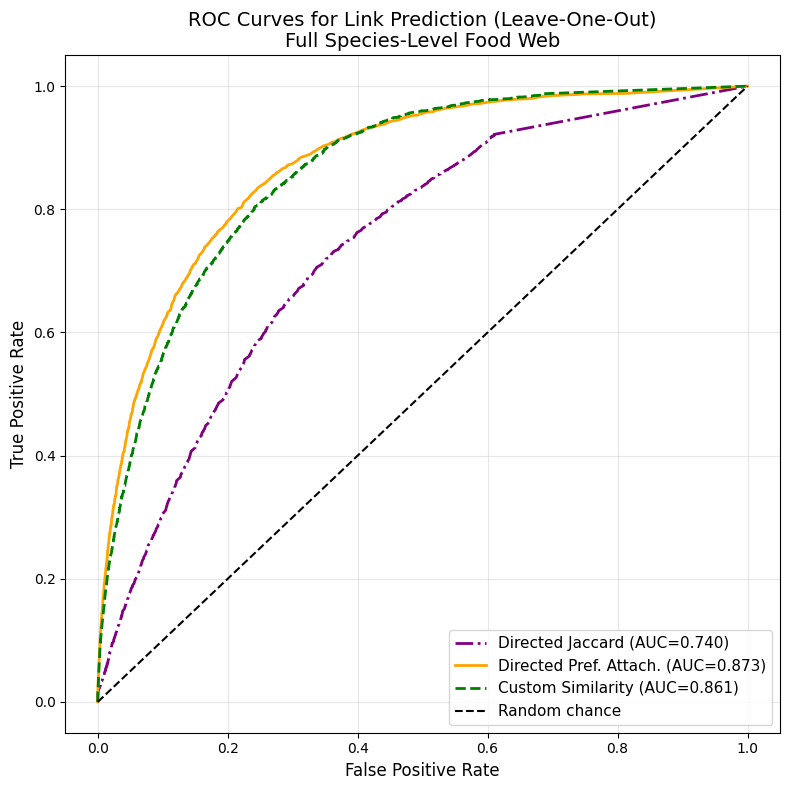

AUC (Directed Jaccard): 0.7399
AUC (Directed Preferential Attachment): 0.8725
AUC (Custom Similarity): 0.8614


In [28]:
# Link prediction on the full species-level graph with custom similarity (G)
print("Running link prediction on full species-level graph with custom similarity...")
print(f"Full graph G: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print("Note: This may take a while due to the large graph size...")

probs_j_full, labels_j_full = getPredictionsLeaveOneOutDirectedJaccard(G, n_neg=10)
probs_pa_full, labels_pa_full = getPredictionsLeaveOneOutDirectedPA(G, n_neg=10)
probs_custom_full, labels_custom_full = getPredictionsLeaveOneOutCustom(G, n_neg=10)

fpr_j_full, tpr_j_full, _ = roc_curve(labels_j_full, probs_j_full)
fpr_pa_full, tpr_pa_full, _ = roc_curve(labels_pa_full, probs_pa_full)
fpr_custom_full, tpr_custom_full, _ = roc_curve(labels_custom_full, probs_custom_full)

auc_j_full = roc_auc_score(labels_j_full, probs_j_full)
auc_pa_full = roc_auc_score(labels_pa_full, probs_pa_full)
auc_custom_full = roc_auc_score(labels_custom_full, probs_custom_full)

plt.figure(figsize=(8, 8))
plt.plot(fpr_j_full, tpr_j_full, "-.", label=f"Directed Jaccard (AUC={auc_j_full:.3f})", color="purple", linewidth=2)
plt.plot(fpr_pa_full, tpr_pa_full, "-", label=f"Directed Pref. Attach. (AUC={auc_pa_full:.3f})", color="orange", linewidth=2)
plt.plot(fpr_custom_full, tpr_custom_full, "--", label=f"Custom Similarity (AUC={auc_custom_full:.3f})", color="green", linewidth=2)
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Link Prediction (Leave-One-Out)\nFull Species-Level Food Web", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC (Directed Jaccard): {auc_j_full:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa_full:.4f}")
print(f"AUC (Custom Similarity): {auc_custom_full:.4f}")


Running link prediction on intertidal subgraph with custom similarity...
Intertidal graph: 231 nodes, 1689 edges


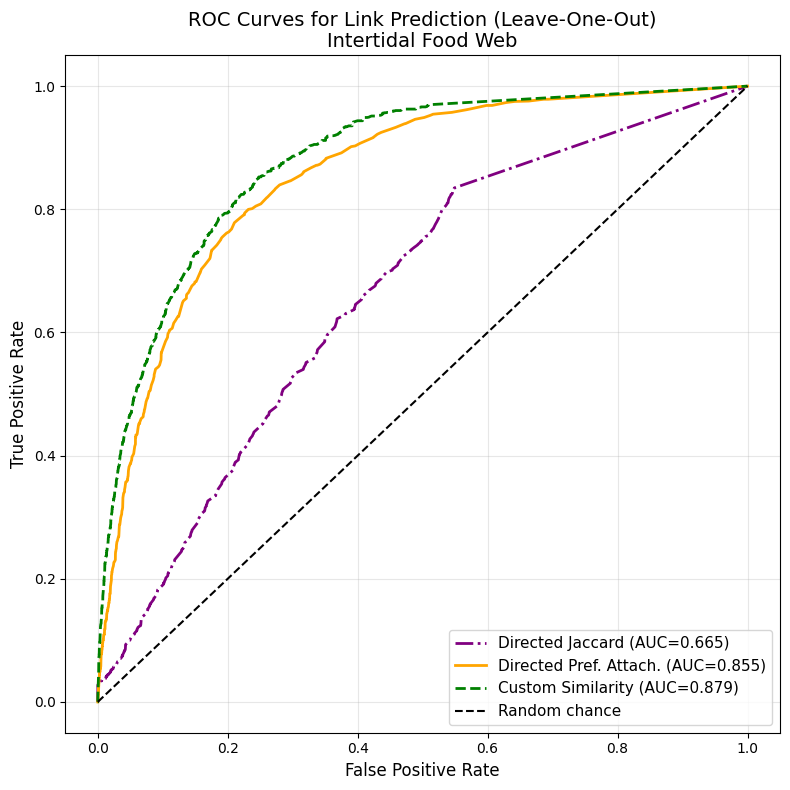

AUC (Directed Jaccard): 0.6647
AUC (Directed Preferential Attachment): 0.8552
AUC (Custom Similarity): 0.8793


In [29]:
# Link prediction on intertidal subgraph with custom similarity
print("Running link prediction on intertidal subgraph with custom similarity...")
print(f"Intertidal graph: {intertidal_G.number_of_nodes()} nodes, {intertidal_G.number_of_edges()} edges")

probs_j_int, labels_j_int = getPredictionsLeaveOneOutDirectedJaccard(intertidal_G, n_neg=10)
probs_pa_int, labels_pa_int = getPredictionsLeaveOneOutDirectedPA(intertidal_G, n_neg=10)
probs_custom_int, labels_custom_int = getPredictionsLeaveOneOutCustom(intertidal_G, n_neg=10)

fpr_j_int, tpr_j_int, _ = roc_curve(labels_j_int, probs_j_int)
fpr_pa_int, tpr_pa_int, _ = roc_curve(labels_pa_int, probs_pa_int)
fpr_custom_int, tpr_custom_int, _ = roc_curve(labels_custom_int, probs_custom_int)

auc_j_int = roc_auc_score(labels_j_int, probs_j_int)
auc_pa_int = roc_auc_score(labels_pa_int, probs_pa_int)
auc_custom_int = roc_auc_score(labels_custom_int, probs_custom_int)

plt.figure(figsize=(8, 8))
plt.plot(fpr_j_int, tpr_j_int, "-.", label=f"Directed Jaccard (AUC={auc_j_int:.3f})", color="purple", linewidth=2)
plt.plot(fpr_pa_int, tpr_pa_int, "-", label=f"Directed Pref. Attach. (AUC={auc_pa_int:.3f})", color="orange", linewidth=2)
plt.plot(fpr_custom_int, tpr_custom_int, "--", label=f"Custom Similarity (AUC={auc_custom_int:.3f})", color="green", linewidth=2)
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Link Prediction (Leave-One-Out)\nIntertidal Food Web", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC (Directed Jaccard): {auc_j_int:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa_int:.4f}")
print(f"AUC (Custom Similarity): {auc_custom_int:.4f}")


Running link prediction on nearshore subgraph with custom similarity...
Nearshore graph: 513 nodes, 6774 edges


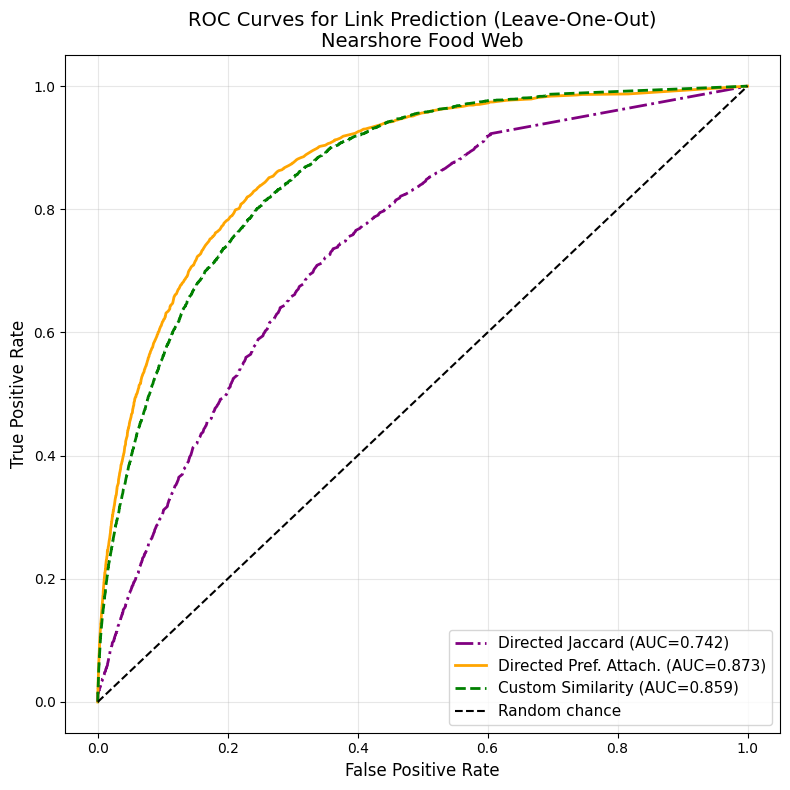

AUC (Directed Jaccard): 0.7419
AUC (Directed Preferential Attachment): 0.8729
AUC (Custom Similarity): 0.8594


In [30]:
# Link prediction on nearshore subgraph with custom similarity
print("Running link prediction on nearshore subgraph with custom similarity...")
print(f"Nearshore graph: {nearshore_G.number_of_nodes()} nodes, {nearshore_G.number_of_edges()} edges")

probs_j_near, labels_j_near = getPredictionsLeaveOneOutDirectedJaccard(nearshore_G, n_neg=10)
probs_pa_near, labels_pa_near = getPredictionsLeaveOneOutDirectedPA(nearshore_G, n_neg=10)
probs_custom_near, labels_custom_near = getPredictionsLeaveOneOutCustom(nearshore_G, n_neg=10)

fpr_j_near, tpr_j_near, _ = roc_curve(labels_j_near, probs_j_near)
fpr_pa_near, tpr_pa_near, _ = roc_curve(labels_pa_near, probs_pa_near)
fpr_custom_near, tpr_custom_near, _ = roc_curve(labels_custom_near, probs_custom_near)

auc_j_near = roc_auc_score(labels_j_near, probs_j_near)
auc_pa_near = roc_auc_score(labels_pa_near, probs_pa_near)
auc_custom_near = roc_auc_score(labels_custom_near, probs_custom_near)

plt.figure(figsize=(8, 8))
plt.plot(fpr_j_near, tpr_j_near, "-.", label=f"Directed Jaccard (AUC={auc_j_near:.3f})", color="purple", linewidth=2)
plt.plot(fpr_pa_near, tpr_pa_near, "-", label=f"Directed Pref. Attach. (AUC={auc_pa_near:.3f})", color="orange", linewidth=2)
plt.plot(fpr_custom_near, tpr_custom_near, "--", label=f"Custom Similarity (AUC={auc_custom_near:.3f})", color="green", linewidth=2)
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Link Prediction (Leave-One-Out)\nNearshore Food Web", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC (Directed Jaccard): {auc_j_near:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa_near:.4f}")
print(f"AUC (Custom Similarity): {auc_custom_near:.4f}")
